# Rapport MS COCO classification challenge

To run this notebook successfully, you need to have the MS COCO dataset downloaded and every python package installed. All python requirements are listed in the appropriate files given in the zip file and was created using uv. You can also create an .env file to provide different variables to the notebook using .env.example as a template.

**Version 2 — what changed compared to the first report notebook** (details in each section):

1. **Validation diagnostic**: a near-duplicate detector checks whether the validation split leaks into the training split (the gap between our validation score and the leaderboard was suspiciously large). The split is now group-aware.
2. **Optimise the real metric**: model selection and thresholds are driven by the leaderboard metric (`inverse_frequency_weighted_f1`), not by macro F1 at 0.5. Thresholds are fitted by coordinate ascent directly on that metric and validated with a split-half check.
3. **Loss / sampling**: Asymmetric Loss (ASL), a softer weighted BCE, and repeat-factor sampling for rare classes.
4. **Backbones / resolution**: EfficientNet-B3, EfficientNet-V2-S, ConvNeXt-Tiny at 288-300 px, mixed precision, OneCycle schedule, EMA, flip TTA.
5. **Submission**: ensemble of the saved runs + thresholds fitted on the ensemble. The final "retrain on train+val" step was removed (see section 14).

## 1. Installation and imports

We start by importing all our libraries needed for this notebook. We also check the version of Python and PyTorch, and we initialize the device to be used (CPU or GPU). Setting DEVICE in the .env is not compulsory as this code will try to detect the best device available. If you want to force the use of a specific device, you can set the DEVICE variable in the .env file to `cpu`, `cuda`, or `mps` for example. If there is an issue with the execution directory, you can also set the `DIR_PATH` variable in your environment variable or change it's value directly in the code below.

In [1]:
import os
import json
import time
import copy
import gc
import platform
import random
import contextlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision

from dotenv import load_dotenv
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm
from torchvision import transforms, models
from torch.utils.data import DataLoader, WeightedRandomSampler
from sklearn.metrics import f1_score, precision_score, recall_score, average_precision_score

pwd = os.getenv("DIR_PATH", "")
os.chdir(pwd) if pwd else None

import sys

PROJECT_DIR = os.getcwd()
if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)
os.environ["PYTHONPATH"] = PROJECT_DIR + os.pathsep + os.environ.get("PYTHONPATH", "")

from lib.util import CLASSES, COCOTrainImageDataset, COCOTestImageDataset, TransformSubset

load_dotenv()

# device initialization
device_name = os.getenv("DEVICE", "")
DEVICE = torch.device(
    device_name) if device_name else (
    torch.accelerator.current_accelerator()) if (
    torch.accelerator.is_available()) else (
    torch.device("cpu"))

print("Python :", platform.python_version())
print("PyTorch :", torch.__version__)
print("Device used :", DEVICE)
print("Execution directory :", os.getcwd())

Python : 3.14.8
PyTorch : 2.14.1
Device used : mps
Execution directory : /Users/ProjetPIR/PR_CR/theo/model


## 2. Configuration

Same idea as before (paths, seed, batch size...), plus the new options of this version: mixed precision (CUDA only), model EMA, flip test-time augmentation (TTA), repeat-factor sampling threshold and the group-aware split. Image size is no longer global: it is set per experiment in section 10.

In [2]:
# Defining global variables for data directories
DATA_ROOT = Path(os.getenv("DATA_ROOT", "/opt/iav/labs/data"))
DATA_ROOT = DATA_ROOT / "ms-coco"
IMAGE_DIR = DATA_ROOT / "images/train"
LABEL_DIR = DATA_ROOT / "labels/train"
TEST_IMAGE_DIR = DATA_ROOT / "images/test"

# Defining global variables for output directories
OUTPUT_DIR = Path(os.getenv("OUTPUT_DIR", "output"))
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
JSON_PATH = OUTPUT_DIR / os.getenv("JSON_PATH", "submission.json")

SEED = 30
EPOCHS = int(os.getenv("EPOCHS", 15))
BATCH_SIZE = int(os.getenv("BATCH_SIZE", 32))
NUM_WORKERS = min(8, os.cpu_count() or 1)

# Fraction of the dataset to be used for validation
VAL_FRACTION = 0.15
# Split train/val by groups of near-duplicate images (see section 6)
DEDUP_SPLIT = True

# Default threshold used only for the simple "@0.5" reference metrics
THRESHOLD = 0.5

# For a quick run, you can set QUICK_RUN to True and limit the number of images processed
# (delete the cached files in OUTPUT_DIR when you switch this flag)
QUICK_RUN = False
QUICK_MAX_IMAGES = 5000

# Speed / training options
PIN_MEMORY = DEVICE.type == "cuda"
USE_AMP = DEVICE.type == "cuda"
AMP_DTYPE = torch.bfloat16 if (USE_AMP and torch.cuda.is_bf16_supported()) else torch.float16
CHANNELS_LAST = DEVICE.type == "cuda"
USE_EMA = True
EMA_DECAY = 0.999
GRAD_CLIP = 5.0
USE_TTA_FLIP = True  # average the prediction of the image and of its horizontal flip
REPEAT_T = 0.02  # repeat-factor sampling: classes in fewer than 2% of the images are oversampled


def amp_ctx():
    return torch.autocast(device_type="cuda", dtype=AMP_DTYPE) if USE_AMP else contextlib.nullcontext()


# Function to set random seed for reproducibility
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = (DEVICE.type == "cuda")


set_seed()

print("Images :", IMAGE_DIR.resolve())
print("Annotations :", LABEL_DIR.resolve())
print("Test images :", TEST_IMAGE_DIR.resolve())
print("Outputs :", OUTPUT_DIR.resolve())
print("Submission :", JSON_PATH.resolve())
print("AMP :", USE_AMP, AMP_DTYPE if USE_AMP else "")

Images : /Users/ProjetPIR/PR_CR/theo/model/data/ms-coco/images/train
Annotations : /Users/ProjetPIR/PR_CR/theo/model/data/ms-coco/labels/train
Test images : /Users/ProjetPIR/PR_CR/theo/model/data/ms-coco/images/test
Outputs : /Users/ProjetPIR/PR_CR/theo/model/output
Submission : /Users/ProjetPIR/PR_CR/theo/model/output/submission.json
AMP : False 


## 3. Classes definitions and files verification

Here we define the classes and verify that we can access the images and annotations. If everything works fine, you should see the number of images and annotations found, and they should be equal to each other (Normally, there is 65 000 images if the dataset is correctly downloaded). You should also see an example of an image and its corresponding annotation file.

In [3]:
classes = CLASSES
NUM_CLASSES = len(classes)
assert NUM_CLASSES == 80, f"We expect to find 80 classes but {NUM_CLASSES} were found."

if not IMAGE_DIR.is_dir() or not LABEL_DIR.is_dir():
    raise FileNotFoundError(
        f"Dataset not found. Verify DATA_ROOT={DATA_ROOT.resolve()} ; "
        f"There must be a folder 'images/train' and a folder 'labels/train' containing the .jpg images and .cls annotation files respectively."
    )

test_images = sorted(IMAGE_DIR.glob("*.jpg"))
label_files = sorted(LABEL_DIR.glob("*.cls"))

if not test_images:
    raise RuntimeError("No .jpg files found in IMAGE_DIR.")
if not label_files:
    raise RuntimeError("No .cls files found in LABEL_DIR.")

print(f"Images : {len(test_images):,}")
print(f"Annotated files : {len(label_files):,}")
print("Image example :", test_images[0].name if test_images else None)
print("annotation example :", label_files[0].name if label_files else None)

if len(test_images) != len(label_files):
    print(
        f"Warning: Number of images ({len(test_images)}) does not match number of labels ({len(label_files)}). Some images may not have corresponding labels or vice versa.")

Images : 65,000
Annotated files : 65,000
Image example : 000000000009.jpg
annotation example : 000000000009.cls


## 4. Annotations analysis

Before going straight to the training part, we will analyze the annotations to see the distribution of classes before any training in order to analyse the composition of the dataset.

Annotations analysis:   0%|          | 0/65000 [00:00<?, ?it/s]

Images analysed : 65000
Annotations problematic : 0
Average number of classes/image : 2.926
Median : 2.0
Min :  1
Max :  18


,class,images_positives
78,hair drier,102
70,toaster,117
12,parking meter,396
21,bear,516
76,scissors,555
...,...,...
41,cup,5057
60,dining table,6546
2,car,6811
56,chair,7043


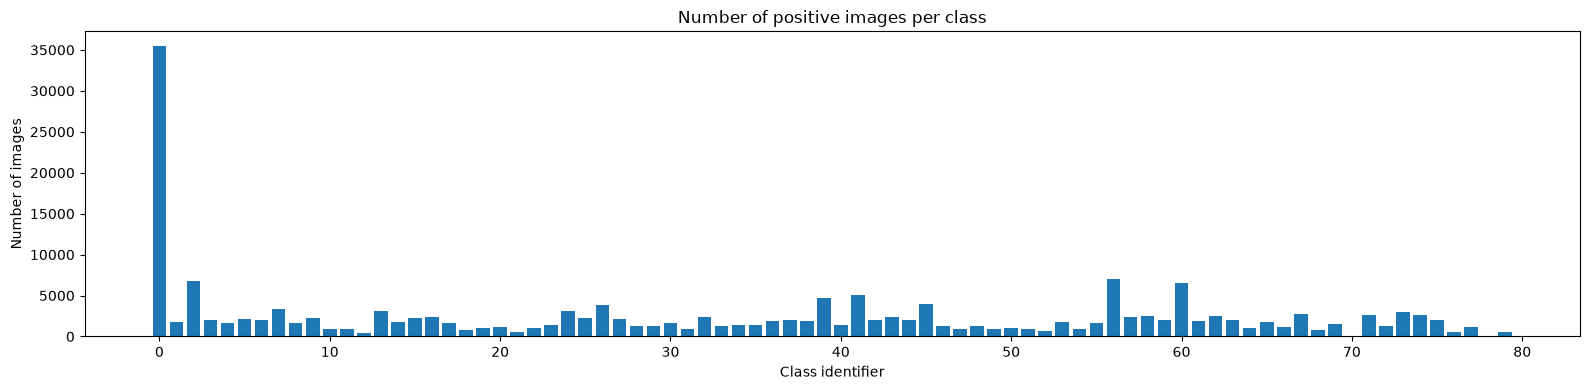

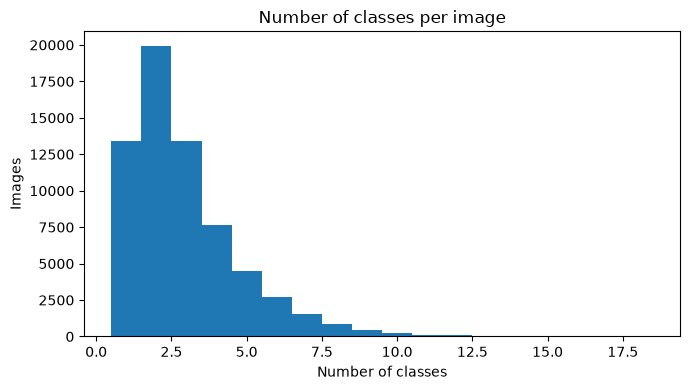

In [4]:
scan_files = label_files[:QUICK_MAX_IMAGES] if QUICK_RUN else label_files
class_counts = np.zeros(NUM_CLASSES, dtype=np.int64)
labels_per_image = []
invalid_rows = []

for p in tqdm(scan_files, desc="Annotations analysis"):
    try:
        ids = [int(x.strip()) for x in p.read_text().splitlines() if x.strip()]
        if any(i < 0 or i >= NUM_CLASSES for i in ids):
            invalid_rows.append(p.name)
            continue
        class_counts[np.unique(ids)] += 1
        labels_per_image.append(len(set(ids)))
    except Exception as e:
        print(f"Error processing {p.name}: {e}")
        invalid_rows.append(p.name)

print("Images analysed :", len(scan_files))
print("Annotations problematic :", len(invalid_rows))
print("Average number of classes/image :", round(float(np.mean(labels_per_image)), 3))
print("Median :", float(np.median(labels_per_image)))
print("Min : ", min(labels_per_image))
print("Max : ", max(labels_per_image))

# Displaying the distribution of images per class in a DataFrame
freq_df = pd.DataFrame({"class": classes, "images_positives": class_counts})
display(freq_df.sort_values("images_positives"))

# Distribution of the number of images per class
plt.figure(figsize=(16, 4))
plt.bar(np.arange(NUM_CLASSES), class_counts)
plt.title("Number of positive images per class")
plt.xlabel("Class identifier")
plt.ylabel("Number of images")
plt.tight_layout()
plt.show()

# Distribution of the number of classes per image
plt.figure(figsize=(7, 4))
plt.hist(labels_per_image, bins=range(1, max(labels_per_image) + 2), align="left")
plt.title("Number of classes per image")
plt.xlabel("Number of classes")
plt.ylabel("Images")
plt.tight_layout()
plt.show()

As we can see, the distribution of classes is highly imbalanced. Firstly, the class "person" is the most represented class by far with 37,000 images. This means that the dataset is heavily biased towards images containing people, which could potentially lead to biased model predictions if not addressed properly. We also have classes with very few images, such as `hair drier` or `toaster` with only roughly 100 images. This extreme imbalance can make it difficult for the model to learn to recognize these underrepresented classes, leading to poor performance on them. The average number of classes per image is around three, which indicates that most images contain multiple objects without overflowing with too many classes. The median number of classes per image is two, which means that half of the images contain two or fewer classes going in the direction of a low number of classes per image.

### Which classes really drive the leaderboard score?

The leaderboard metric (`inverse_frequency_weighted_f1`) averages precision and recall with weights proportional to `1 / n_positives`, then takes the F1 of these two averages. So a class with 100 images weighs about 350 times more than `person`. The next cell shows how concentrated the metric is: the model must be good on the rare classes, and a very high global accuracy on frequent classes barely moves the score.

In [5]:
metric_w = 1.0 / np.maximum(class_counts, 1)
metric_w = metric_w / metric_w.sum()
share_df = pd.DataFrame({"class": classes, "images_positives": class_counts, "metric_weight": metric_w})
share_df = share_df.sort_values("metric_weight", ascending=False).reset_index(drop=True)
share_df["cumulative_weight"] = share_df["metric_weight"].cumsum()
display(share_df.head(15))
print(f"The 10 rarest classes carry {share_df['metric_weight'].head(10).sum():.0%} of the leaderboard metric.")

,class,images_positives,metric_weight,cumulative_weight
0,hair drier,102,0.136382,0.136382
1,toaster,117,0.118897,0.255279
2,parking meter,396,0.035129,0.290408
3,bear,516,0.026959,0.317367
4,scissors,555,0.025065,0.342432
5,toothbrush,561,0.024797,0.367228
6,hot dog,667,0.020856,0.388084
7,sheep,809,0.017195,0.405279
8,microwave,832,0.016720,0.421999
9,donut,856,0.016251,0.438251


The 10 rarest classes carry 44% of the leaderboard metric.


## 5. Dataset PyTorch

The PyTorch Dataset classes for training and testing are defined in `lib/util.py` and imported at the beginning of this notebook. These classes will handle loading the images and their corresponding labels, applying any necessary transformations, and preparing the data for training and evaluation. They are based on the provided function given in the starting notebook.

## 6. Split, transformations and DataLoaders

**Why the split changed.** In the first notebook, validation F1 macro reached 0.885 (leaderboard-style F1 of 0.665) while the leaderboard gives about 0.44. A gap this large usually means that the validation set is *easier* than the test set, for example because near-identical images (same photo re-exported, flipped, slightly cropped...) end up on both sides of a random split. In that case every choice made on validation (best epoch, thresholds, model selection) is biased.

The cells below (1) compute a cheap 64-bit perceptual hash of every image (also of its horizontal flip), (2) measure how many validation images have a near-duplicate in the training split, and how many test images have one in the train set, and (3) build the split **by groups of near-duplicates**. If the dataset has no duplicates, the groups are singletons and this is simply a random split.

**Other changes.**
- Train transform: same light augmentation as before (flip + light colour jitter). No `RandomResizedCrop`, because a crop can remove an object that is still in the label (label noise).
- Validation / test: the whole image is resized (no centre crop), so objects on the borders are never cut out.
- Image size is chosen per experiment; the loaders are rebuilt for each one but always use the same split.
- Optional repeat-factor sampling (LVIS-style): an image is repeated `r = max over its classes of max(1, sqrt(t / f_c))` times on average, `f_c` being the fraction of images containing class `c`. The validation set is never resampled, so thresholds tuned on it stay valid for the real distribution.

In [6]:
IMAGENET_MEAN, IMAGENET_STD = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)
max_images = QUICK_MAX_IMAGES if QUICK_RUN else None


def make_transforms(img_size):
    train_tf = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])
    eval_tf = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])
    return train_tf, eval_tf


# ---------- near-duplicate detection (64-bit dHash, flip aware) ----------
def compute_dhash(dataset, batch_size=128):
    """Return (bits, bits_flip), two boolean arrays (N, 64): dHash of each image and of its horizontal flip."""
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS)
    bits, bits_flip = [], []
    for batch in tqdm(loader, desc="dHash"):
        g = batch[0][:, 0]  # (B, 8, 9) grayscale
        bits.append((g[:, :, 1:] > g[:, :, :-1]).reshape(len(g), 64).numpy())
        gf = torch.flip(g, dims=[2])
        bits_flip.append((gf[:, :, 1:] > gf[:, :, :-1]).reshape(len(g), 64).numpy())
    return np.concatenate(bits), np.concatenate(bits_flip)


def near_duplicate_pairs(bits_a, bits_b, same, max_dist=3, max_bucket=200):
    """Pairs (i, j) with Hamming distance <= max_dist. Pigeonhole: with 4 chunks of 16 bits, at most 3 differing
    bits means at least one identical chunk, so we only compare images that share a chunk."""
    w = (1 << np.arange(16)).astype(np.int64)
    key = lambda b: b.reshape(len(b), 4, 16).astype(np.int64) @ w
    ka, kb = key(bits_a), key(bits_b)
    cand = set()
    for ch in range(4):
        buckets = {}
        for j, k in enumerate(kb[:, ch]):
            buckets.setdefault(int(k), []).append(j)
        for i, k in enumerate(ka[:, ch]):
            bucket = buckets.get(int(k), ())
            if len(bucket) > max_bucket:
                continue  # flat / blank images: skip degenerate buckets
            for j in bucket:
                if not same or j > i:
                    cand.add((i, j))
    if not cand:
        return np.zeros((0, 2), dtype=np.int64)
    cand = np.array(sorted(cand), dtype=np.int64)
    dist = (bits_a[cand[:, 0]] != bits_b[cand[:, 1]]).sum(1)
    return cand[dist <= max_dist]


def duplicate_pairs_flip_aware(bits, bits_flip):
    n = len(bits)
    both = np.concatenate([bits, bits_flip])  # image and flipped image are the same photo
    p = near_duplicate_pairs(both, both, same=True)
    p = np.stack([p[:, 0] % n, p[:, 1] % n], axis=1) if len(p) else p
    p = p[p[:, 0] != p[:, 1]] if len(p) else p
    return np.unique(np.sort(p, axis=1), axis=0) if len(p) else p


def group_ids_from_pairs(n, pairs):
    parent = np.arange(n)

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    for i, j in pairs:
        ri, rj = find(i), find(j)
        if ri != rj:
            parent[rj] = ri
    return np.array([find(i) for i in range(n)])


def grouped_split(groups, val_fraction, seed):
    rng = np.random.RandomState(seed)
    uniq, counts = np.unique(groups, return_counts=True)
    order = rng.permutation(len(uniq))
    target, val_groups, total = int(len(groups) * val_fraction), [], 0
    for k in order:
        if total >= target:
            break
        val_groups.append(uniq[k])
        total += counts[k]
    is_val = np.isin(groups, val_groups)
    return np.flatnonzero(~is_val), np.flatnonzero(is_val)


def leak_rate(pairs, train_idx, val_idx, n):
    side = np.zeros(n, dtype=np.int8)
    side[train_idx], side[val_idx] = 1, 2
    leaked = np.zeros(n, dtype=bool)
    for i, j in pairs:
        if side[i] == 2 and side[j] == 1: leaked[i] = True
        if side[j] == 2 and side[i] == 1: leaked[j] = True
    return leaked[val_idx].mean() if len(val_idx) else 0.0


# ---------- dataset + hashes (cached) ----------
base_dataset = COCOTrainImageDataset(IMAGE_DIR, LABEL_DIR, transform=None, maximum_images=max_images)
N_TOTAL = len(base_dataset)
hash_tf = transforms.Compose([transforms.Resize((8, 9)), transforms.Grayscale(), transforms.ToTensor()])

train_hash_path = OUTPUT_DIR / "dhash_train.npz"
if train_hash_path.exists() and len(np.load(train_hash_path)["bits"]) == N_TOTAL:
    h = np.load(train_hash_path);
    tr_bits, tr_bits_flip = h["bits"], h["bits_flip"]
else:
    tr_bits, tr_bits_flip = compute_dhash(
        COCOTrainImageDataset(IMAGE_DIR, LABEL_DIR, transform=hash_tf, maximum_images=max_images))
    np.savez_compressed(train_hash_path, bits=tr_bits, bits_flip=tr_bits_flip)

dup_pairs = duplicate_pairs_flip_aware(tr_bits, tr_bits_flip)
groups = group_ids_from_pairs(N_TOTAL, dup_pairs)
print(f"Near-duplicate pairs inside the training folder : {len(dup_pairs):,} "
      f"| images belonging to a group of size > 1 : {(np.bincount(groups)[groups] > 1).mean():.1%}")

# ---------- how bad would a plain random split be ? ----------
n_val = max(1, int(N_TOTAL * VAL_FRACTION))
generator = torch.Generator().manual_seed(SEED)
rand_train, rand_val = torch.utils.data.random_split(base_dataset, [N_TOTAL - n_val, n_val], generator=generator)
rand_train_idx, rand_val_idx = np.array(rand_train.indices), np.array(rand_val.indices)
print(f"Random split : {leak_rate(dup_pairs, rand_train_idx, rand_val_idx, N_TOTAL):.1%} of the validation images "
      f"have a near-duplicate in the training split")

# ---------- how similar is the TEST set to the train set ? ----------
if TEST_IMAGE_DIR.is_dir():
    test_hash_path = OUTPUT_DIR / "dhash_test.npz"
    if test_hash_path.exists():
        h = np.load(test_hash_path);
        te_bits, te_bits_flip = h["bits"], h["bits_flip"]
    else:
        te_bits, te_bits_flip = compute_dhash(COCOTestImageDataset(TEST_IMAGE_DIR, transform=hash_tf))
        np.savez_compressed(test_hash_path, bits=te_bits, bits_flip=te_bits_flip)
    tp = near_duplicate_pairs(np.concatenate([te_bits, te_bits_flip]), tr_bits, same=False)
    test_with_dup = len(np.unique(tp[:, 0] % len(te_bits))) / len(te_bits) if len(tp) else 0.0
    print(f"Test images with a near-duplicate in the train folder : {test_with_dup:.1%}")
    print("-> if the random-split leak is much larger than this number, validation scores are inflated.")

# ---------- final split ----------
if DEDUP_SPLIT:
    train_idx, val_idx = grouped_split(groups, VAL_FRACTION, SEED)
else:
    train_idx, val_idx = rand_train_idx, rand_val_idx
train_subset = torch.utils.data.Subset(base_dataset, train_idx.tolist())
val_subset = torch.utils.data.Subset(base_dataset, val_idx.tolist())
print(
    f"Split ({'group-aware' if DEDUP_SPLIT else 'random'}) -> train : {len(train_subset):,} | validation : {len(val_subset):,}")

# ---------- training targets (for sampler, loss, bias init) ----------
_, _eval_tf_small = make_transforms(32)
_tmp = TransformSubset(train_subset, _eval_tf_small)
if hasattr(_tmp, "targets"):
    TRAIN_TARGETS = np.asarray(_tmp.targets, dtype=np.float32)
else:
    TRAIN_TARGETS = np.concatenate([y.numpy() for _, y in
                                    DataLoader(_tmp, batch_size=256, shuffle=False, num_workers=NUM_WORKERS)])
assert TRAIN_TARGETS.shape == (len(train_subset), NUM_CLASSES), TRAIN_TARGETS.shape
del _tmp

_prior = np.clip(TRAIN_TARGETS.mean(0), 1e-4, 0.5)
PRIOR_LOGITS = np.log(_prior / (1 - _prior)).astype(np.float32)  # head bias init = log-odds of each class


def repeat_factor_weights(targets, t=REPEAT_T):
    freq = targets.mean(0)
    r_class = np.maximum(1.0, np.sqrt(t / np.maximum(freq, 1e-12)))
    r_img = (targets * r_class[None, :]).max(1)
    return np.where(r_img == 0, 1.0, r_img)


_w = repeat_factor_weights(TRAIN_TARGETS)
_rare = np.argsort(TRAIN_TARGETS.sum(0))[:5]
_eff = (_w[:, None] * TRAIN_TARGETS).sum(0) / _w.sum() * len(_w)
print("Rarest classes, images seen per epoch (raw -> with repeat-factor sampling):")
for c in _rare:
    print(f"  {classes[c]:<14s} {int(TRAIN_TARGETS[:, c].sum()):>5d} -> {_eff[c]:.0f}")


def make_loaders(img_size, use_rfs):
    train_tf, eval_tf = make_transforms(img_size)
    train_ds = TransformSubset(train_subset, train_tf)
    val_ds = TransformSubset(val_subset, eval_tf)
    sampler = None
    if use_rfs:
        sampler = WeightedRandomSampler(torch.as_tensor(repeat_factor_weights(TRAIN_TARGETS), dtype=torch.double),
                                        num_samples=len(train_ds), replacement=True)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=(sampler is None), sampler=sampler,
                              num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=True,
                              persistent_workers=NUM_WORKERS > 0)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
                            pin_memory=PIN_MEMORY, persistent_workers=NUM_WORKERS > 0)
    return train_loader, val_loader


def make_test_loader(img_size):
    _, eval_tf = make_transforms(img_size)
    test_ds = COCOTestImageDataset(TEST_IMAGE_DIR, transform=eval_tf)
    return DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

dHash:   0%|          | 0/508 [00:04<?, ?it/s]

Near-duplicate pairs inside the training folder : 708 | images belonging to a group of size > 1 : 0.8%
Random split : 0.9% of the validation images have a near-duplicate in the training split


dHash:   0%|          | 0/39 [00:04<?, ?it/s]

Test images with a near-duplicate in the train folder : 0.6%
-> if the random-split leak is much larger than this number, validation scores are inflated.
Split (group-aware) -> train : 55,250 | validation : 9,750
Rarest classes, images seen per epoch (raw -> with repeat-factor sampling):
  hair drier        90 -> 297
  toaster           98 -> 310
  parking meter    340 -> 577
  bear             438 -> 655
  toothbrush       455 -> 680


## 7. Metrics computation

We keep the original metric functions (`compute_metrics`, `inverse_frequency_weighted_f1`) and add everything needed to **optimise the leaderboard metric directly**:

- `pr_tables` pre-computes, for every class and every candidate threshold, the precision and the recall. The leaderboard metric is then just a weighted sum over classes, which makes it cheap to evaluate.
- `optimize_thresholds` starts from the best *global* threshold, then runs a coordinate ascent: classes are visited from the most to the least weighted, and a class threshold is changed only if the **global leaderboard F1 strictly improves**.
- Rare classes have very few positives in validation, so per-class thresholds can overfit. `cv_threshold_scores` measures this honestly: thresholds are fitted on one half of the validation set and scored on the other half. We compare three strategies (`global`, `per_class`, and `blend` = average of both) and keep the best one on held-out data.
- `apply_thresholds` can force at least one label per image (every COCO image has at least one) by taking the class with the highest `p / threshold`.
- We also log `mAP` and an inverse-frequency-weighted `mAP` (threshold-free, same weighting as the leaderboard); the latter is used to pick the best epoch.

In [7]:
THR_GRID = np.round(np.arange(0.05, 0.951, 0.05), 3)


def compute_metrics(y_true, y_prob, threshold=THRESHOLD):
    y_pred = (y_prob >= threshold).astype(np.uint8)
    return {
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_micro": f1_score(y_true, y_pred, average="micro", zero_division=0),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
    }


def inverse_frequency_weighted_f1(y_true, y_pred):
    positives = y_true.sum(axis=0)
    tp = ((y_true == 1) & (y_pred == 1)).sum(axis=0)
    fp = ((y_true == 0) & (y_pred == 1)).sum(axis=0)
    precision = np.divide(tp, tp + fp, out=np.zeros_like(tp, dtype=float), where=(tp + fp) > 0)
    recall = np.divide(tp, positives, out=np.zeros_like(tp, dtype=float), where=positives > 0)
    weights = np.divide(1.0, positives, out=np.zeros_like(positives, dtype=float), where=positives > 0)
    if weights.sum() == 0: return 0.0
    weights = weights / weights.sum()
    p, r = np.sum(precision * weights), np.sum(recall * weights)
    return 0.0 if p + r == 0 else 2 * p * r / (p + r)


def class_weights(y_true):
    pos = y_true.sum(0).astype(float)
    w = np.divide(1.0, pos, out=np.zeros_like(pos), where=pos > 0)
    return w / w.sum()


def pr_tables(y_true, y_prob, grid=THR_GRID):
    """precision[c, t], recall[c, t] for every class c and candidate threshold t."""
    y = y_true.astype(bool)
    C, T = y.shape[1], len(grid)
    prec, rec = np.zeros((C, T)), np.zeros((C, T))
    pos = y.sum(0)
    for c in range(C):
        pred = y_prob[:, c, None] >= grid[None, :]
        tp = (pred & y[:, c, None]).sum(0)
        npred = pred.sum(0)
        prec[c] = np.divide(tp, npred, out=np.zeros(T), where=npred > 0)
        rec[c] = tp / pos[c] if pos[c] > 0 else 0.0
    return prec, rec


def _f1(P, R):
    return np.where(P + R > 0, 2 * P * R / np.maximum(P + R, 1e-12), 0.0)


def optimize_thresholds(y_true, y_prob, grid=THR_GRID, passes=3):
    """Coordinate ascent on the leaderboard metric. Returns (per-class thresholds, score, best global score)."""
    prec, rec = pr_tables(y_true, y_prob, grid)
    w = class_weights(y_true)
    C, T = prec.shape
    ar = np.arange(C)
    glob = np.array([_f1((w * prec[:, j]).sum(), (w * rec[:, j]).sum()) for j in range(T)])
    idx = np.full(C, int(np.argmax(glob)))
    best = float(glob.max())
    for _ in range(passes):
        P, R = (w * prec[ar, idx]).sum(), (w * rec[ar, idx]).sum()
        changed = False
        for c in np.argsort(-w):
            if w[c] == 0:
                continue
            Pn = P - w[c] * prec[c, idx[c]] + w[c] * prec[c]
            Rn = R - w[c] * rec[c, idx[c]] + w[c] * rec[c]
            F = _f1(Pn, Rn)
            j = int(np.argmax(F))
            if F[j] > best + 1e-9:
                idx[c], P, R, best, changed = j, Pn[j], Rn[j], float(F[j]), True
        if not changed:
            break
    return grid[idx], best, float(glob.max())


def optimize_global_threshold(y_true, y_prob, grid=THR_GRID):
    prec, rec = pr_tables(y_true, y_prob, grid)
    w = class_weights(y_true)
    scores = [_f1((w * prec[:, j]).sum(), (w * rec[:, j]).sum()) for j in range(len(grid))]
    return float(grid[int(np.argmax(scores))])


def fit_thresholds(y_true, y_prob, mode):
    C = y_true.shape[1]
    g = optimize_global_threshold(y_true, y_prob)
    if mode == "global":
        return np.full(C, g)
    pc, _, _ = optimize_thresholds(y_true, y_prob)
    return pc if mode == "per_class" else 0.5 * pc + 0.5 * g  # mode == "blend"


def apply_thresholds(y_prob, thr, force_one=True):
    pred = y_prob >= thr[None, :]
    if force_one:
        rows = np.flatnonzero(~pred.any(1))
        if len(rows):
            pred[rows, (y_prob[rows] / thr[None, :]).argmax(1)] = True
    return pred.astype(np.uint8)


def cv_threshold_scores(y_true, y_prob, n_repeats=3, seed=0):
    """Held-out leaderboard F1 of each (mode, force_one) strategy: fit on one half of the validation set, score on the other."""
    rng = np.random.RandomState(seed)
    scores = {}
    for _ in range(n_repeats):
        perm = rng.permutation(len(y_true))
        half = len(perm) // 2
        for a, b in ((perm[:half], perm[half:]), (perm[half:], perm[:half])):
            for mode in ("global", "blend", "per_class"):
                thr = fit_thresholds(y_true[a], y_prob[a], mode)
                for force in (False, True):
                    s = inverse_frequency_weighted_f1(y_true[b], apply_thresholds(y_prob[b], thr, force))
                    scores.setdefault((mode, force), []).append(s)
    return {k: float(np.mean(v)) for k, v in scores.items()}


def average_precisions(y_true, y_prob):
    aps = np.zeros(y_true.shape[1])
    for c in range(y_true.shape[1]):
        if y_true[:, c].sum() > 0:
            aps[c] = average_precision_score(y_true[:, c], y_prob[:, c])
    return aps


def epoch_metrics(y_true, y_prob):
    aps = average_precisions(y_true, y_prob)
    has_pos = y_true.sum(0) > 0
    _, lb_per_class, lb_global = optimize_thresholds(y_true, y_prob)
    return {"mAP": float(aps[has_pos].mean()), "mAP_w": float((aps * class_weights(y_true)).sum()),
            "lb_f1_global": lb_global, "lb_f1_per_class": lb_per_class}

## 8. Pretrained models and losses

All backbones are ImageNet-pretrained torchvision models whose last linear layer is replaced by an 80-output head. Two details matter for this imbalanced problem:

- **Head bias initialised to the log-odds of each class** (as in RetinaNet): at the start the model already predicts "rare" for rare classes instead of 0.5, which avoids a huge initial loss from the thousands of negatives.
- **Differential learning rates**: the new head uses `head_lr_mult` times the backbone learning rate.

Losses:
- `bce`: plain binary cross-entropy (baseline).
- `weighted_bce`: `pos_weight = neg / pos` (the original version). For a class with 100 positives that is a weight of about 650, which tends to wreck precision.
- `wbce_sqrt`: the same with a square root (weight about 25 for the rarest class), a much gentler version.
- `asl`: Asymmetric Loss (Ridnik et al., 2021), designed for multi-label problems where negatives vastly outnumber positives. It down-weights easy negatives (`gamma_neg = 4`, plus a probability margin `clip = 0.05`) while keeping the full gradient on positives (`gamma_pos = 0`). Note that ASL shifts the output probabilities, so the tuned thresholds below matter even more than with BCE.

In [8]:
MODEL_REGISTRY = {
    # name: (constructor, weights enum, attribute holding the classification head)
    "resnet18": (models.resnet18, models.ResNet18_Weights, "fc"),
    "resnet50": (models.resnet50, models.ResNet50_Weights, "fc"),
    "efficientnet_b0": (models.efficientnet_b0, models.EfficientNet_B0_Weights, "classifier"),
    "efficientnet_b3": (models.efficientnet_b3, models.EfficientNet_B3_Weights, "classifier"),
    "efficientnet_v2_s": (models.efficientnet_v2_s, models.EfficientNet_V2_S_Weights, "classifier"),
    "convnext_tiny": (models.convnext_tiny, models.ConvNeXt_Tiny_Weights, "classifier"),
}


def replace_head(model, head_attr):
    head = getattr(model, head_attr)
    if isinstance(head, nn.Linear):
        new = nn.Linear(head.in_features, NUM_CLASSES)
        setattr(model, head_attr, new)
        return new
    last = len(head) - 1
    assert isinstance(head[last], nn.Linear), f"unexpected head for {head_attr}"
    head[last] = nn.Linear(head[last].in_features, NUM_CLASSES)
    return head[last]


def build_model(backbone="resnet18", pretrained=True, freeze_backbone=False):
    ctor, weights_enum, head_attr = MODEL_REGISTRY[backbone]
    model = ctor(weights=weights_enum.DEFAULT if pretrained else None)
    linear = replace_head(model, head_attr)
    with torch.no_grad():
        linear.bias.copy_(torch.as_tensor(PRIOR_LOGITS))
    if freeze_backbone:
        for name, p in model.named_parameters():
            if not name.startswith(head_attr + "."): p.requires_grad = False
    model = model.to(DEVICE)
    if CHANNELS_LAST:
        model = model.to(memory_format=torch.channels_last)
    return model, head_attr


class AsymmetricLoss(nn.Module):
    """ASL (Ridnik et al., ICCV 2021). Returns the loss summed over classes and averaged over the batch."""

    def __init__(self, gamma_neg=4.0, gamma_pos=0.0, clip=0.05, eps=1e-8):
        super().__init__()
        self.gamma_neg, self.gamma_pos, self.clip, self.eps = gamma_neg, gamma_pos, clip, eps

    def forward(self, logits, targets):
        logits = logits.float()
        p = torch.sigmoid(logits)
        p_neg = 1.0 - p
        if self.clip > 0:
            p_neg = (p_neg + self.clip).clamp(max=1.0)
        loss = targets * torch.log(p.clamp(min=self.eps)) + (1.0 - targets) * torch.log(p_neg.clamp(min=self.eps))
        with torch.no_grad():
            pt = p * targets + p_neg * (1.0 - targets)
            gamma = self.gamma_pos * targets + self.gamma_neg * (1.0 - targets)
            focus = torch.pow(1.0 - pt, gamma)
        return -(loss * focus).sum() / logits.shape[0]


def make_criterion(loss_name, train_targets=None):
    if loss_name == "bce":
        return nn.BCEWithLogitsLoss()
    if loss_name in ("weighted_bce", "wbce_sqrt"):
        pos = train_targets.sum(axis=0)
        ratio = (len(train_targets) - pos) / np.maximum(pos, 1)
        if loss_name == "wbce_sqrt":
            ratio = np.sqrt(ratio)
        return nn.BCEWithLogitsLoss(pos_weight=torch.tensor(ratio, dtype=torch.float32, device=DEVICE))
    if loss_name == "asl":
        return AsymmetricLoss(gamma_neg=4.0, gamma_pos=0.0, clip=0.05)
    raise ValueError(f"Unknown loss : {loss_name}")

## 9. Training and evaluation loop

Compared to the first version:

- **OneCycle schedule** (10% warm-up, cosine decay). With the old constant learning rate the validation loss was still falling at epoch 10, i.e. the model was stopped before converging, and the learning rate never decayed. There is no early stopping any more because it would cut the annealing; instead we keep the **best epoch**, selected on the weighted mAP (threshold-free, same weighting as the leaderboard).
- **Mixed precision** (CUDA) and `channels_last` for speed, gradient clipping.
- **EMA** of the weights (usually a free gain for the final model); the EMA model is the one evaluated and saved.
- **Flip TTA** for the final validation/test predictions.
- Each run writes its validation/test probabilities to `OUTPUT_DIR` (`*_val_probs.npy`, `*_test_probs.npy`). Section 13 builds the final submission from these files, so experiments can be run one at a time (and resumed after a crash).

In [9]:
class ModelEMA:
    def __init__(self, model, decay=EMA_DECAY):
        self.module = copy.deepcopy(model).eval()
        for p in self.module.parameters():
            p.requires_grad_(False)
        self.decay, self.updates = decay, 0

    @torch.no_grad()
    def update(self, model):
        self.updates += 1
        d = min(self.decay, (1 + self.updates) / (10 + self.updates))
        src = model.state_dict()
        for k, v in self.module.state_dict().items():
            if v.dtype.is_floating_point:
                v.mul_(d).add_(src[k].detach(), alpha=1 - d)
            else:
                v.copy_(src[k])


def _prep(images):
    images = images.to(DEVICE, non_blocking=True)
    return images.contiguous(memory_format=torch.channels_last) if CHANNELS_LAST else images


@torch.no_grad()
def predict_loader(model, loader, criterion=None, tta=False):
    model.eval()
    probs_all, targets_all, loss_sum, seen = [], [], 0.0, 0
    for images, targets in tqdm(loader, leave=False, desc="validation"):
        x = _prep(images)
        with amp_ctx():
            logits = model(x)
            logits_flip = model(torch.flip(x, dims=[3])) if tta else None
        logits = logits.float()
        probs = torch.sigmoid(logits)
        if tta:
            probs = 0.5 * (probs + torch.sigmoid(logits_flip.float()))
        if criterion is not None:
            loss_sum += criterion(logits, targets.to(DEVICE)).item() * x.size(0)
            seen += x.size(0)
        probs_all.append(probs.cpu().numpy())
        targets_all.append(targets.numpy())
    return np.concatenate(targets_all), np.concatenate(probs_all), loss_sum / max(seen, 1)


@torch.no_grad()
def predict_test(model, loader, tta=False):
    model.eval()
    ids, probs_all = [], []
    for images, names in tqdm(loader, leave=False, desc="test"):
        x = _prep(images)
        with amp_ctx():
            logits = model(x)
            logits_flip = model(torch.flip(x, dims=[3])) if tta else None
        probs = torch.sigmoid(logits.float())
        if tta:
            probs = 0.5 * (probs + torch.sigmoid(logits_flip.float()))
        probs_all.append(probs.cpu().numpy())
        ids.extend(list(names))
    return ids, np.concatenate(probs_all)


def fit_experiment(name, backbone="resnet18", pretrained=True, freeze_backbone=False, loss_name="bce",
                   lr=1e-4, head_lr_mult=10.0, weight_decay=1e-2, img_size=224, use_rfs=False,
                   epochs=EPOCHS, use_ema=USE_EMA):
    set_seed()
    start = time.time()
    train_loader, val_loader = make_loaders(img_size, use_rfs)
    model, head_attr = build_model(backbone, pretrained, freeze_backbone)
    criterion = make_criterion(loss_name, TRAIN_TARGETS)

    params = [(n, p) for n, p in model.named_parameters() if p.requires_grad]
    groups_ = [{"params": [p for n, p in params if n.startswith(head_attr + ".")], "lr": lr * head_lr_mult}]
    body = [p for n, p in params if not n.startswith(head_attr + ".")]
    if body:
        groups_.append({"params": body, "lr": lr})
    optimizer = torch.optim.AdamW(groups_, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=[g["lr"] for g in groups_], total_steps=epochs * len(train_loader),
        pct_start=0.1, anneal_strategy="cos", div_factor=20, final_div_factor=100, cycle_momentum=False)
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP and AMP_DTYPE == torch.float16)
    ema = ModelEMA(model) if use_ema else None

    best_score, best_state, best_epoch, history = -1.0, None, 0, []
    for epoch in range(epochs):
        model.train()
        running, seen = torch.zeros((), device=DEVICE), 0
        for images, targets in tqdm(train_loader, desc=f"{name} - epoch {epoch + 1}/{epochs}", leave=False):
            images, targets = _prep(images), targets.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with amp_ctx():
                logits = model(images)
            loss = criterion(logits.float(), targets)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            if ema is not None:
                ema.update(model)
            running += loss.detach() * images.size(0)
            seen += images.size(0)

        eval_model = ema.module if ema is not None else model
        y_val, p_val, val_loss = predict_loader(eval_model, val_loader, criterion, tta=False)
        row = {"experiment": name, "epoch": epoch + 1, "train_loss": float(running) / max(seen, 1),
               "val_loss": val_loss, **epoch_metrics(y_val, p_val), "lr": optimizer.param_groups[-1]["lr"]}
        history.append(row)
        print({k: round(v, 4) if isinstance(v, (float, np.floating)) else v for k, v in row.items()})
        if row["mAP_w"] > best_score:
            best_score, best_epoch = row["mAP_w"], epoch + 1
            best_state = {k: v.detach().cpu().clone() for k, v in eval_model.state_dict().items()}
            torch.save({"state_dict": best_state, "backbone": backbone, "img_size": img_size, "loss_name": loss_name,
                        "classes": list(classes)}, OUTPUT_DIR / f"{name}_best.pt")

    # ---- final predictions of the best epoch (with TTA) ----
    eval_model = ema.module if ema is not None else model
    eval_model.load_state_dict(best_state)
    y_val, p_val, _ = predict_loader(eval_model, val_loader, None, tta=USE_TTA_FLIP)
    test_ids, p_test = predict_test(eval_model, make_test_loader(img_size), tta=USE_TTA_FLIP)

    np.save(OUTPUT_DIR / f"{name}_val_probs.npy", p_val.astype(np.float32))
    np.save(OUTPUT_DIR / f"{name}_test_probs.npy", p_test.astype(np.float32))
    targets_path, ids_path = OUTPUT_DIR / "val_targets.npy", OUTPUT_DIR / "test_ids.json"
    if targets_path.exists():
        assert np.array_equal(np.load(targets_path),
                              y_val), "validation split changed between runs - delete the cached files"
    else:
        np.save(targets_path, y_val.astype(np.uint8))
    if ids_path.exists():
        assert json.load(open(ids_path)) == list(test_ids), "test order changed between runs"
    else:
        json.dump(list(test_ids), open(ids_path, "w"))

    hist_df = pd.DataFrame(history)
    hist_df.to_csv(OUTPUT_DIR / f"{name}_history.csv", index=False)
    summary = {"experiment": name, "backbone": backbone, "loss": loss_name, "img_size": img_size, "rfs": use_rfs,
               "lr": lr, "epochs": epochs, "best_epoch": best_epoch, **epoch_metrics(y_val, p_val),
               "seconds": time.time() - start}
    json.dump(summary, open(OUTPUT_DIR / f"{name}_summary.json", "w"), indent=2)

    del train_loader, val_loader, model, ema, eval_model, optimizer
    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    return hist_df, summary

## 10. Experiments

Suggested order (each experiment answers one question; the first three are cheap ResNet18 runs):

| Experiment | Question it answers |
|---|---|
| `r18_bce_224` | New pipeline (schedule, thresholds on the real metric, TTA) with the **same model as before**: how much comes from the pipeline alone? |
| `r18_asl_224` | Does ASL beat BCE? |
| `r18_asl_rfs_224` | Does repeat-factor sampling of rare classes help on top of ASL? |
| `effb3_asl_rfs_300`, `convnext_t_asl_rfs_288`, `effv2s_asl_rfs_300` | Bigger backbones at higher resolution, with the best loss/sampling found above (edit the `loss_name` / `use_rfs` of these entries if the cheap runs say otherwise). |

Learning rates are starting values (backbone lr; the head uses 10x). `RUN` selects what is trained in this session: finished experiments are skipped (their results are read from `OUTPUT_DIR`), set `FORCE_RERUN = True` to retrain them.

In [10]:
EXPERIMENTS = [
    dict(name="r18_bce_224", backbone="resnet18", loss_name="bce", lr=2e-4, img_size=224),
    dict(name="r18_asl_224", backbone="resnet18", loss_name="asl", lr=2e-4, img_size=224),
    dict(name="r18_asl_rfs_224", backbone="resnet18", loss_name="asl", lr=2e-4, img_size=224, use_rfs=True),
    dict(name="effb3_asl_rfs_300", backbone="efficientnet_b3", loss_name="asl", lr=2e-4, img_size=300, use_rfs=True),
    dict(name="convnext_t_asl_rfs_288", backbone="convnext_tiny", loss_name="asl", lr=8e-5, weight_decay=5e-2,
         img_size=288, use_rfs=True),
    dict(name="effv2s_asl_rfs_300", backbone="efficientnet_v2_s", loss_name="asl", lr=2e-4, img_size=300, use_rfs=True),
]

RUN = ["r18_bce_224", "r18_asl_224", "r18_asl_rfs_224"]
FORCE_RERUN = False

for cfg in EXPERIMENTS:
    if cfg["name"] not in RUN:
        continue
    if (OUTPUT_DIR / f"{cfg['name']}_summary.json").exists() and not FORCE_RERUN:
        print(f"{cfg['name']} : already done, skipped")
        continue
    print(f"===== {cfg['name']} =====")
    fit_experiment(**cfg, epochs=EPOCHS)

===== r18_bce_224 =====


r18_bce_224 - epoch 1/15:   0%|          | 0/1726 [00:04<?, ?it/s]

validation:   0%|          | 0/305 [00:04<?, ?it/s]

{'experiment': 'r18_bce_224', 'epoch': 1, 'train_loss': 0.0836, 'val_loss': 0.0588, 'mAP': 0.6556, 'mAP_w': 0.5053, 'lb_f1_global': 0.4868, 'lb_f1_per_class': 0.5314, 'lr': 0.0002}


r18_bce_224 - epoch 2/15:   0%|          | 0/1726 [00:00<?, ?it/s]

...

r18_asl_rfs_224 - epoch 15/15:   0%|          | 0/1726 [00:00<?, ?it/s]

validation:   0%|          | 0/305 [00:00<?, ?it/s]

{'experiment': 'r18_asl_rfs_224', 'epoch': 15, 'train_loss': 0.2588, 'val_loss': 0.19, 'mAP': 0.9957, 'mAP_w': 0.9977, 'lb_f1_global': 0.9898, 'lb_f1_per_class': 0.9912, 'lr': 0.0}


validation:   0%|          | 0/305 [00:00<?, ?it/s]

test:   0%|          | 0/155 [00:04<?, ?it/s]

## 11. Results visualization

All finished experiments found in `OUTPUT_DIR` are compared on the validation set. `lb_f1_per_class` is optimistic (thresholds are tuned and scored on the same data); the honest comparison, with held-out thresholds, is done in section 13. Use `mAP_w` (weighted like the leaderboard, threshold-free) and `lb_f1_global` to compare models.

,experiment,backbone,loss,img_size,rfs,best_epoch,mAP,mAP_w,lb_f1_global,lb_f1_per_class,seconds
0,r18_asl_rfs_224,resnet18,asl,224,True,15,0.998336,0.999037,0.994777,0.995858,3877.650242
1,r18_bce_224,resnet18,bce,224,False,15,0.999698,0.998024,0.994409,0.994692,3233.620047
2,r18_asl_224,resnet18,asl,224,False,15,0.999289,0.997726,0.989014,0.993706,3691.490659


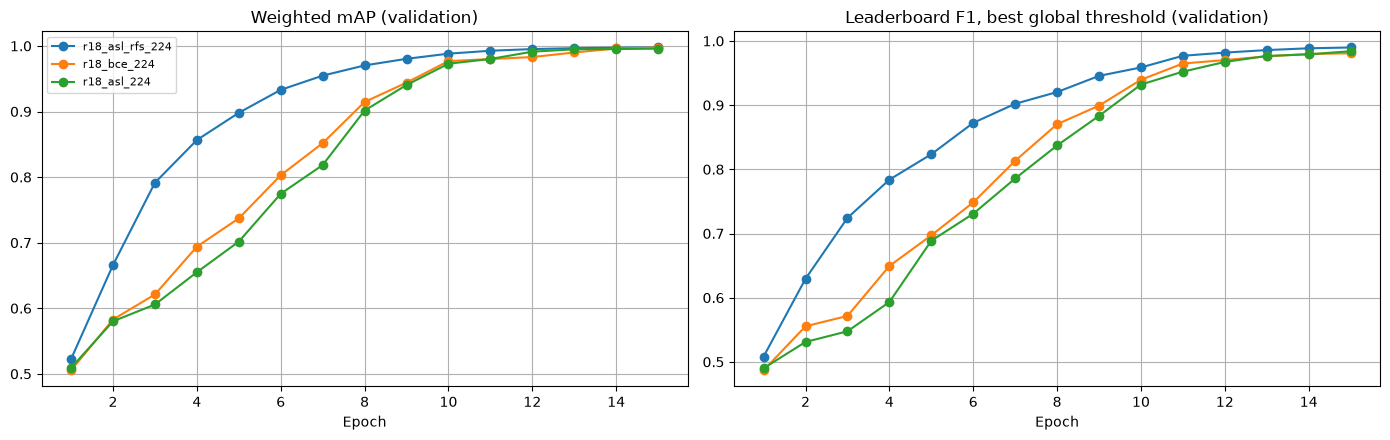

In [11]:
summaries = [json.load(open(p)) for p in sorted(OUTPUT_DIR.glob("*_summary.json"))]
results_df = pd.DataFrame(summaries).sort_values("mAP_w", ascending=False).reset_index(drop=True)
display(results_df[["experiment", "backbone", "loss", "img_size", "rfs", "best_epoch", "mAP", "mAP_w",
                    "lb_f1_global", "lb_f1_per_class", "seconds"]])
results_df.to_csv(OUTPUT_DIR / "experiment_results.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for name in results_df["experiment"]:
    hist = pd.read_csv(OUTPUT_DIR / f"{name}_history.csv")
    axes[0].plot(hist["epoch"], hist["mAP_w"], marker="o", label=name)
    axes[1].plot(hist["epoch"], hist["lb_f1_global"], marker="o", label=name)
axes[0].set_title("Weighted mAP (validation)");
axes[1].set_title("Leaderboard F1, best global threshold (validation)")
for ax in axes:
    ax.set_xlabel("Epoch");
    ax.grid(True)
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 12. Ensemble and threshold selection

The final prediction is the **average of the probabilities of the top-K runs** (ranked by weighted mAP), K = 1 ... 4. For each K, and for each threshold strategy (`global`, `blend`, `per_class`, with or without forcing one label per image), we compute the **held-out** leaderboard F1 with the split-half procedure of section 7. We keep the (K, strategy) with the best held-out score, then refit the thresholds on the whole validation set.

The held-out score is the number to compare with the leaderboard (it is still computed on validation, so it is only as trustworthy as the split: see the duplicate diagnostic of section 6).

In [12]:
y_val = np.load(OUTPUT_DIR / "val_targets.npy")
ranked = list(results_df["experiment"])
val_probs = {n: np.load(OUTPUT_DIR / f"{n}_val_probs.npy") for n in ranked}
test_probs = {n: np.load(OUTPUT_DIR / f"{n}_test_probs.npy") for n in ranked}

rows, best = [], None
for k in range(1, min(4, len(ranked)) + 1):
    members = ranked[:k]
    p = np.mean([val_probs[n] for n in members], axis=0)
    cv = cv_threshold_scores(y_val, p)
    for (mode, force), score in cv.items():
        rows.append({"K": k, "members": "+".join(members), "mode": mode, "force_one": force, "heldout_lb_f1": score})
        if best is None or score > best["score"]:
            best = {"score": score, "K": k, "members": members, "mode": mode, "force_one": force}
cv_df = pd.DataFrame(rows).sort_values("heldout_lb_f1", ascending=False)
display(cv_df.head(12))

FINAL_MEMBERS, FINAL_MODE, FORCE_ONE = best["members"], best["mode"], best["force_one"]
p_val_final = np.mean([val_probs[n] for n in FINAL_MEMBERS], axis=0)
final_thresholds = fit_thresholds(y_val, p_val_final, FINAL_MODE)
in_sample = inverse_frequency_weighted_f1(y_val, apply_thresholds(p_val_final, final_thresholds, FORCE_ONE))
print("Selected members :", FINAL_MEMBERS)
print("Threshold strategy :", FINAL_MODE, "| force one label :", FORCE_ONE)
print(f"Held-out leaderboard F1 (expected) : {best['score']:.4f} | in-sample : {in_sample:.4f}")
print("Thresholds (min / median / max) :", final_thresholds.min(), np.median(final_thresholds), final_thresholds.max())

,K,members,mode,force_one,heldout_lb_f1
9,2,r18_asl_rfs_224+r18_bce_224,blend,True,0.999283
8,2,r18_asl_rfs_224+r18_bce_224,blend,False,0.999283
6,2,r18_asl_rfs_224+r18_bce_224,global,False,0.999279
7,2,r18_asl_rfs_224+r18_bce_224,global,True,0.999279
11,2,r18_asl_rfs_224+r18_bce_224,per_class,True,0.999143
10,2,r18_asl_rfs_224+r18_bce_224,per_class,False,0.999143
15,3,r18_asl_rfs_224+r18_bce_224+r18_asl_224,blend,True,0.998120
14,3,r18_asl_rfs_224+r18_bce_224+r18_asl_224,blend,False,0.998120
13,3,r18_asl_rfs_224+r18_bce_224+r18_asl_224,global,True,0.998074
12,3,r18_asl_rfs_224+r18_bce_224+r18_asl_224,global,False,0.998074


Selected members : ['r18_asl_rfs_224', 'r18_bce_224']
Threshold strategy : blend | force one label : False
Held-out leaderboard F1 (expected) : 0.9993 | in-sample : 0.9994
Thresholds (min / median / max) : 0.5 0.6 0.6499999999999999


## 13. Per-class metrics

Precision, recall and F1 of every class with the final thresholds, together with the weight of the class in the leaderboard metric. The classes with the highest `metric_weight` and a low F1 are where the next improvements are.

In [13]:
y_pred = apply_thresholds(p_val_final, final_thresholds, FORCE_ONE)
w_val = class_weights(y_val)
per_class = []
for c, cname in enumerate(classes):
    per_class.append({
        "class": cname, "positifs_validation": int(y_val[:, c].sum()), "metric_weight": w_val[c],
        "precision": precision_score(y_val[:, c], y_pred[:, c], zero_division=0),
        "recall": recall_score(y_val[:, c], y_pred[:, c], zero_division=0),
        "f1": f1_score(y_val[:, c], y_pred[:, c], zero_division=0),
        "threshold": final_thresholds[c],
    })
per_class_df = pd.DataFrame(per_class)
per_class_df["f1_loss_x_weight"] = (1 - per_class_df["f1"]) * per_class_df["metric_weight"]
display(per_class_df.sort_values("f1_loss_x_weight", ascending=False).head(20))
per_class_df.to_csv(OUTPUT_DIR / "per_class_validation_metrics.csv", index=False)

,class,positifs_validation,metric_weight,precision,recall,f1,threshold,f1_loss_x_weight
64,mouse,152,0.013372,0.986842,0.986842,0.986842,0.650,0.000176
44,spoon,284,0.007157,0.989437,0.989437,0.989437,0.600,0.000076
49,orange,147,0.013827,0.993243,1.000000,0.996610,0.650,0.000047
28,suitcase,209,0.009725,0.995215,0.995215,0.995215,0.575,0.000047
66,keyboard,167,0.012171,1.000000,0.994012,0.996997,0.575,0.000037
40,wine glass,183,0.011107,1.000000,0.994536,0.997260,0.600,0.000030
24,backpack,441,0.004609,0.997717,0.990930,0.994312,0.625,0.000026
43,knife,349,0.005824,0.994286,0.997135,0.995708,0.625,0.000025
42,fork,300,0.006775,0.996667,0.996667,0.996667,0.625,0.000023
26,handbag,575,0.003535,0.991349,0.996522,0.993929,0.600,0.000021


## 14. Test submission

The test probabilities of the selected runs are averaged, the thresholds of section 12 are applied, and the JSON file is written. Before submitting, compare the three printed averages: the average number of predicted labels per image on test should be close to the one on validation (and to the true average of about 2.9 labels per image). A large difference means that the test set does not behave like our validation set.

In [14]:
test_ids = json.load(open(OUTPUT_DIR / "test_ids.json"))
p_test_final = np.mean([test_probs[n] for n in FINAL_MEMBERS], axis=0)
pred_test = apply_thresholds(p_test_final, final_thresholds, FORCE_ONE)

output_dict = {tid: np.flatnonzero(row).astype(int).tolist() for tid, row in zip(test_ids, pred_test)}
json_path = OUTPUT_DIR / "submission.json"
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(output_dict, f, ensure_ascii=False, indent=2)

print("JSON created :", json_path.resolve())
print("Number of predicted images :", len(output_dict))
print(f"Avg labels / image - true val : {y_val.sum(1).mean():.2f} | predicted val : {y_pred.sum(1).mean():.2f} "
      f"| predicted test : {pred_test.sum(1).mean():.2f}")
print("Example :", next(iter(output_dict.items())) if output_dict else "empty")

JSON created : /Users/ProjetPIR/PR_CR/theo/model/output/submission.json
Number of predicted images : 4952
Avg labels / image - true val : 2.90 | predicted val : 2.90 | predicted test : 2.23
Example : ('000000000139', [56, 57, 58, 60, 62, 73, 75])


## 15. Submission verification

We verify that the generated JSON file is valid and contains one entry per **test** image (the first version compared the ids with the *train* folder).

In [15]:
with open(json_path, "r", encoding="utf-8") as f:
    submission_check = json.load(f)

expected_ids = {p.stem for p in TEST_IMAGE_DIR.glob("*.jpg") if p.is_file()}
submitted_ids = set(submission_check)
assert submitted_ids == expected_ids, (
    f"images offset : {len(expected_ids - submitted_ids)} missing, "
    f"{len(submitted_ids - expected_ids)} unexpected. (If your ids are not file stems, adapt expected_ids.)"
)
for image_id, ids in submission_check.items():
    assert isinstance(image_id, str)
    assert isinstance(ids, list)
    assert all(isinstance(i, int) and 0 <= i < NUM_CLASSES for i in ids), image_id
    assert len(ids) == len(set(ids)), f"duplicate identifier {image_id}"
print("All tested passed.")
print("You can submit the file to the leaderboard :", json_path.resolve())

All tested passed.
You can submit the file to the leaderboard : /Users/ProjetPIR/PR_CR/theo/model/output/submission.json
